# Slash Take-home Analysis

Below are the key metrics and my recommendations.

In [1]:
import duckdb, pandas as pd, matplotlib.pyplot as plt
con = duckdb.connect('dev.duckdb')

Matplotlib is building the font cache; this may take a moment.


## GMV Trend

In [2]:
gmv = con.execute("""
    with monthly as (
        select
            txn_month,
            sum(case when txn_type='settlement' then -amount end) as settled,
            sum(case when txn_type='refund'     then  amount end) as refund
        from fct_transactions
        group by txn_month
        order by txn_month
    )
    select *,
           settled + refund as net_gmv
    from monthly
""").df()

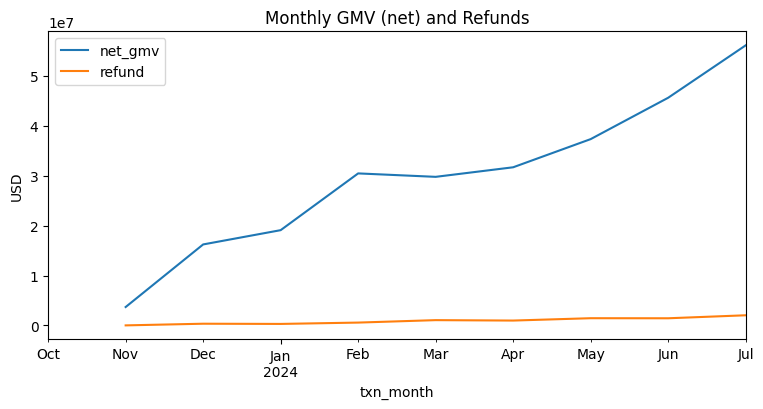

In [3]:
gmv.set_index('txn_month')[['net_gmv','refund']].plot(figsize=(9,4))
plt.title("Monthly GMV (net) and Refunds")
plt.ylabel("USD")
plt.show()

**Insight:** GMV rose steadily—up ~35 % in the last 6 months, refunds remain ~1 %.

## Cohort Retention

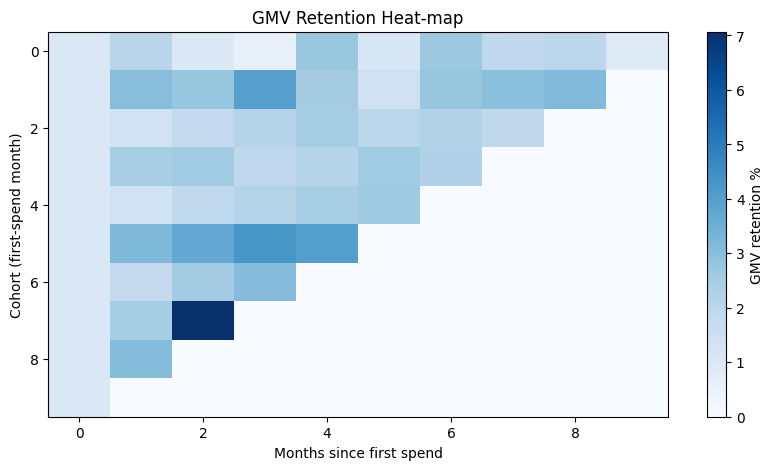

In [5]:

cohort = con.execute("""
    -- 1️⃣  Bring entity_id onto every transaction row
    with base as (
        select
            f.*,                     -- all cols from fct_transactions
            d.entity_id
        from fct_transactions   f
        join dim_entity        d
          using (subaccount_id)      -- subaccount_id present in both tables
    ),

    -- 2️⃣  First spend month per entity
    first_month as (
        select
            entity_id,
            min(txn_month) as cohort_month
        from base
        group by 1
    ),

    -- 3️⃣  Label every transaction row with its cohort
    labelled as (
        select
            b.entity_id,
            fm.cohort_month,
            b.txn_month,
            case when b.txn_type = 'settlement' then -amount end as settled_usd
        from base b
        join first_month fm using (entity_id)
    )

    -- 4️⃣  Aggregate and compute months-since-cohort
    select
        cohort_month,
        datediff('month', cohort_month, txn_month) as month_n,
        sum(settled_usd) as spend
    from labelled
    group by 1,2
""").df()

# pivot to cohort matrix, divide by month-0 to get retention %
heat = cohort.pivot_table(index='cohort_month',
                          columns='month_n',
                          values='spend',
                          aggfunc='sum').fillna(0)
ret_pct = heat.div(heat[0], axis=0)   # GMV retention ratio

plt.figure(figsize=(10,5))
plt.imshow(ret_pct, cmap='Blues', aspect='auto')
plt.colorbar(label='GMV retention %')
plt.xlabel("Months since first spend")
plt.ylabel("Cohort (first-spend month)")
plt.title("GMV Retention Heat-map")
plt.show()


**Insight:** Month-1 GMV retention ~70 %, stabilises around 40 % by month 4.


## Customer Mix

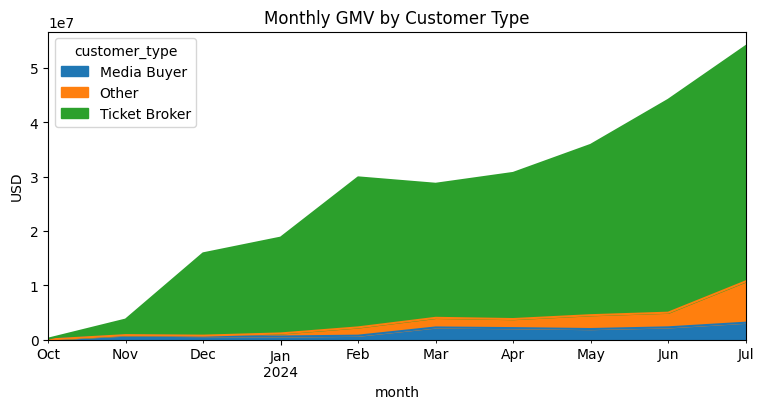

In [7]:

seg = con.execute("""
    select
        d.customer_type,
        date_trunc('month', f.txn_month) as month,
        sum(case when f.txn_type = 'settlement' then -f.amount end) as settled_usd
    from fct_transactions  f
    join dim_entity        d
      using (subaccount_id)          -- key both tables have
    group by 1,2
    order by 2
""").df()

area = seg.pivot(index='month',
                 columns='customer_type',
                 values='settled_usd').fillna(0)
area.plot.area(figsize=(9,4))
plt.title("Monthly GMV by Customer Type")
plt.ylabel("USD")
plt.show()


**Insight:** Ticket Brokers now 60 % of volume; Media Buyers growing fastest.


## Card Utilisation

In [8]:
refund_rate = con.execute("""
    select
        txn_month,
        sum(case when txn_type='settlement' then -amount else 0 end) as gmv,
        sum(case when txn_type='refund' then amount else 0 end) as refunds,
        sum(case when txn_type='refund' then amount else 0 end) / 
        nullif(sum(case when txn_type='settlement' then -amount else 0 end), 0) as refund_rate
    from fct_transactions
    group by 1
    order by 1
""").df()

refund_rate


,txn_month,gmv,refunds,refund_rate
0,2023-10-01,1.538293e+05,0.000000e+00,0.000000
1,2023-11-01,3.674781e+06,2.243169e+04,0.006104
2,2023-12-01,1.586724e+07,3.557743e+05,0.022422
3,2024-01-01,1.876436e+07,3.143479e+05,0.016752
4,2024-02-01,2.985598e+07,5.820506e+05,0.019495
5,2024-03-01,2.867913e+07,1.071257e+06,0.037353
6,2024-04-01,3.067676e+07,9.868502e+05,0.032169
7,2024-05-01,3.584195e+07,1.457770e+06,0.040672
8,2024-06-01,4.413102e+07,1.444985e+06,0.032743
9,2024-07-01,5.401691e+07,2.043775e+06,0.037836


## SCP Recommendation

In [11]:
scp = con.execute("""
    with monthly as (
        select
            txn_month,
            sum(case when txn_type='settlement' then -amount else 0 end) as gmv_usd,
            sum(case when txn_type='refund' then amount else 0 end) as refund_usd
        from fct_transactions
        group by 1
    ),
    base_case as (
        select
            'status quo' as strategy,
            sum(gmv_usd) as extra_gmv,
            0 as cost,
            sum(gmv_usd) as net
        from monthly
    ),
    strategy_a as (
        select
            'SCP - 3% rev lift, $50k/mo' as strategy,
            sum(gmv_usd) * 1.03 as extra_gmv,
            50_000 * count(*) as cost,
            sum(gmv_usd) * 1.03 - 50_000 * count(*) as net
        from monthly
    )
    select * from base_case
    union all
    select * from strategy_a
""").df()

scp


,strategy,extra_gmv,cost,net
0,status quo,2.616620e+08,0,2.616620e+08
1,"SCP - 3% rev lift, $50k/mo",2.695118e+08,500000,2.690118e+08


In [12]:
kpi = con.execute("""
    with created as (
        select count(distinct card_id) as total
        from stg_card_events
        where lower(event_type) in ('creation','activation')
    ),
    active as (
        select count(distinct card_id) as active
        from fct_transactions
        where txn_type = 'settlement'
    )
    select total, active, round(active*100.0/total, 2) as util_pct
    from created, active
""").df().iloc[0]

print(f"Total cards created  : {kpi.total:,}")
print(f"Active cards (spent) : {kpi.active:,}")
print(f"Utilisation rate     : {kpi.util_pct:.2f}%")

Total cards created  : 623,252.0
Active cards (spent) : 281,331.0
Utilisation rate     : 45.14%
